In [9]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
eps = 1
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
m_dm = 1e-27
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
hbar = 1.0545718e-34 

In [10]:
# RF pseudo-force
def FRF(x,y,z,m=c.m,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    # --- FORCE EVERYTHING TO SCALARS ---
    x = float(x)
    y = float(y)
    z = float(z)
    m = float(np.asarray(m).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    Zc = float(np.asarray(Z_charge).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z_charge*q)/(2*pi*np.sqrt(m)*omrf))**2*np.array([divypartz*0,divzparty+divyparty,divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,x,y,z,v): # gradient term of DC potential
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.array([divx,divy,divz])

def FDC_single(x1,y1,x2,y2,x,y,z,v):
    return -Z_charge*e * (anatangrad(x2,y2,x,y,z,v)-anatangrad(x2,y1,x,y,z,v)-anatangrad(x1,y2,x,y,z,v)+anatangrad(x1,y1,x,y,z,v))

def FDC(x, y, z, m=c.m, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    z_original = z
    force = np.zeros(3, dtype=float)
    # local copies forced to scalars (if these could be arrays)
    x = float(x); y = float(y); z_original = float(z_original)
    for k in range(0, 40):
        if (k != 19 and k != 39):
            z = z_original - z_offset  # keep scalar math
        else:
            z = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, x, y, z, v_k)
        # ensure force_single is shape (3,)
        force_single = np.asarray(force_single, dtype=float).ravel()
        if force_single.shape != (3,):
            raise ValueError(f"FDC_single returned unexpected shape {force_single.shape} at k={k}")
        force += force_single
        # restore z (already set above each iteration; explicit restore optional)
        z = z_original
    return force

Ending position of DM: [4.96e-04 5.00e-06 0.00e+00]
Ending velocity of DM: [52.6  0.   0. ]


/tmp/ipykernel_15188/2471107468.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_15188/2471107468.py:116: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_15188/2471107468.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


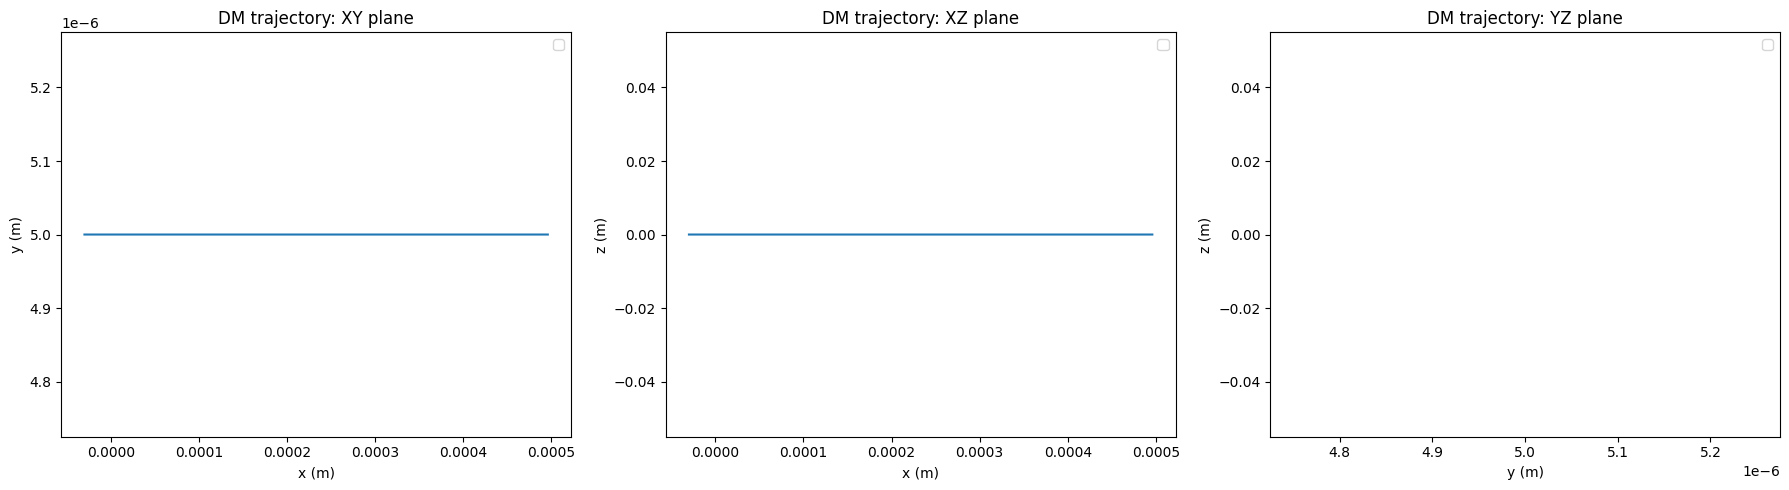

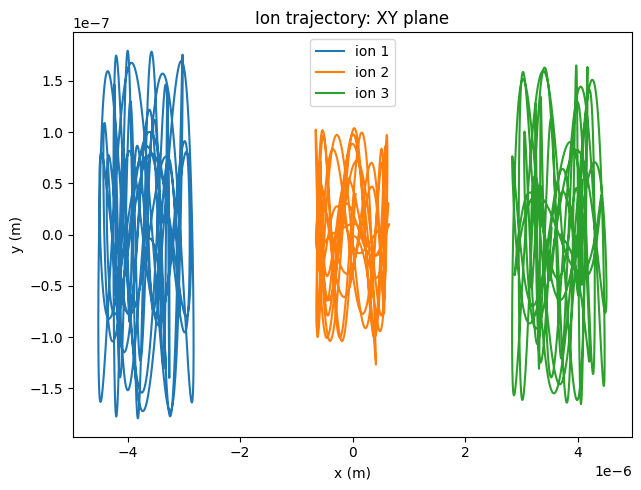

/tmp/ipykernel_15188/2471107468.py:190: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


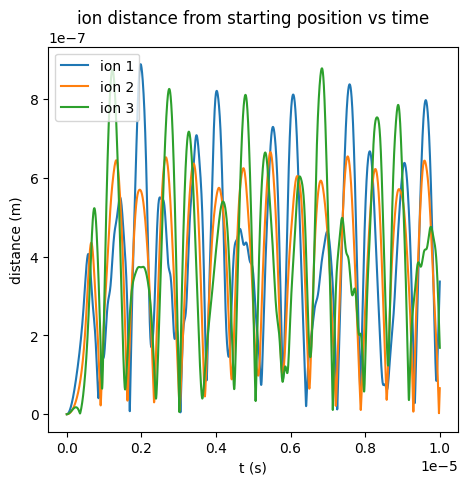

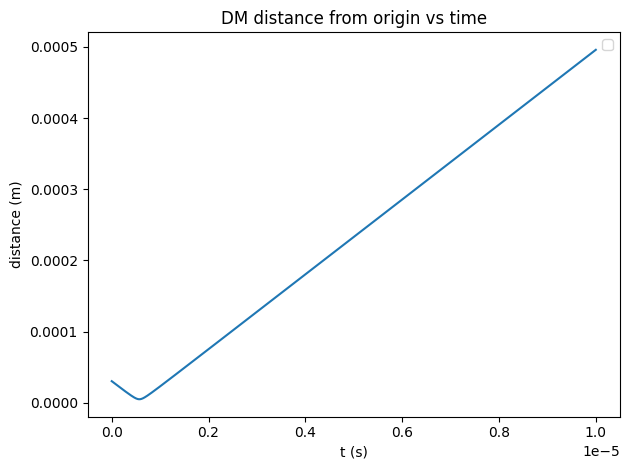

In [16]:
### Combined

def run_simulation():
    n_ions = 3 # adjust ion count
    
    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        # Local n_ions for reshaping logic
        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM) ---
        dc_dm = np.asarray(FDC(*x_dm))
        rf_dm = np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        
        #dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):
            if use_harmonic_ions:
                dv_ionsdt[i] += -omega**2 * (x_ions[i])
                #dv_ionsdt[i] += -omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)
            # Use softening if needed, but for verification r^3 is fine
            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            #dv_dmdt      -= force / m_dm 

            # --- Ion <-> Ion Coulomb (Skipped for n=1) ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)
                fij = K * e**2 * delta_ij / r_ij**3
                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])
    
    # Ion initial conditions
    x0_ions = np.array([
        [-d_chain,0,0],
        [0,0,0],
        [d_chain,0,0]
    ], dtype=float)
    v0_ions = np.zeros_like(x0_ions, dtype=float)
    
    # DM initial conditions
    x0_dm = np.array([-30e-6, 5e-6, 0.0], dtype=float) # Start 30um back
    v0_dm = np.array([52.6, 0, 0], dtype=float)

    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Solve
    t_eval = np.linspace(0, 10e-6, 5000) # 2 microseconds
    t_span = (0, 10e-6)
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                    t_eval=t_eval, rtol=1e-12, atol=1e-12, args=(x0_ions,))

    # Extract
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]
    v_dm_sol   = sol.y[-3:] # Final 3 are always v_dm

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol

# Run simulations
t0, xdm0, vdm0, xion0 = run_simulation() 
x0, y0, z0 = xdm0
x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion
d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
print(f"Ending position of DM: {xdm0[:, -1]}")
print(f"Ending velocity of DM: {vdm0[:, -1]}")

## Plots of the DM trajectory
plt.figure(figsize=(18,5))

# XY
plt.subplot(1,3,1)
plt.plot(x0, y0)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("DM trajectory: XY plane")
plt.legend()

# XZ
plt.subplot(1,3,2)
plt.plot(x0, z0)
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: XZ plane")
plt.legend()

# YZ
plt.subplot(1,3,3)
plt.plot(y0, z0)
plt.xlabel("y (m)")
plt.ylabel("z (m)")
plt.title("DM trajectory: YZ plane")
plt.legend()

plt.tight_layout()
plt.show()

## Plots for ion trajectory
plt.figure(figsize=(18,5))

# ion 1 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion1, y0_ion1, label="ion 1")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 2 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion2, y0_ion2, label="ion 2")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

# ion 3 XY-trajectory
plt.subplot(1,3,1)
plt.plot(x0_ion3, y0_ion3, label="ion 3")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ion trajectory: XY plane")
plt.legend()

plt.tight_layout()
plt.show()

# ion 1 distance vs time
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.plot(t0, d_ion1, label="ion 1")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 2 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion2, label="ion 2")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# ion 3 distance vs time
plt.subplot(1,3,1)
plt.plot(t0, d_ion3, label="ion 3")
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("ion distance from starting position vs time")
plt.legend()

# DM distance vs time
plt.figure()
plt.plot(t0, d)
plt.xlabel("t (s)")
plt.ylabel("distance (m)")
plt.title("DM distance from origin vs time")
plt.legend()

plt.tight_layout()
plt.show()

## Comparison with Rutherford Scattering


In [12]:
## Test 1: DM moves very quickly, comparison to Rutherford scattering
# --- 1. Analysis Logic ---

# 1. Observed Angle
v_initial = vdm0[:, 0]
v_final   = vdm0[:, -1]
cos_theta = np.dot(v_initial, v_final) / (np.linalg.norm(v_initial) * np.linalg.norm(v_final))
theta_obs = np.arccos(np.clip(cos_theta, -1, 1))

# 2. Predicted Angle
# Impact parameter is the initial Y-offset
b_val = 5e-7 
v_mag = 1e6

# Calculate using the full formula
numerator = K * eps * Z * e**2
denominator = m_dm * (v_mag**2) * b_val
theta_pred = 2 * np.arctan(numerator / denominator)

print(f"--- Updated Rutherford Verification ---")
print(f"Impact Parameter (b): {b_val:.2e} m")
print(f"Initial Velocity: {v_mag:.2e} m/s")
print(f"Observed Angle: {np.degrees(theta_obs):.8f}°")
print(f"Predicted Angle: {np.degrees(theta_pred):.8f}°")
print(f"New Percent Error: {abs(theta_obs - theta_pred)/theta_pred * 100:.4f}%")

# --- 2. Scattering Visualization ---

plt.figure(figsize=(10, 6))

# Plot DM Trajectory (Projected onto the XY plane for visualization)
plt.plot(xdm0[0], xdm0[1], 'b-', label="Simulated DM Path")

# Plot Ions
plt.scatter([-d_chain, 0, d_chain], [0, 0, 0], color='red', marker='o', label="Ions")

# Plot Rutherford Asymptotes
# We draw a line from the start and a line following the deflection angle
x_ext = np.linspace(min(xdm0[0]), max(xdm0[0]), 100)
# Final direction vector normalized
v_dir = v_final / np.linalg.norm(v_final)
# Trace back from final position
plt.plot(xdm0[0, -1] - v_dir[0]*x_ext, xdm0[1, -1] - v_dir[1]*x_ext, 
         'g--', alpha=0.5, label="Final Velocity Asymptote")

plt.axhline(0, color='black', alpha=0.2)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"DM Scattering Angle Verification\n(v_initial = {v_mag_inf:.1e} m/s)")
plt.legend()
plt.axis('equal') # Crucial to see the actual angle geometrically
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

NameError: name 'Z' is not defined